In [35]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('../my_style.mplstyle')

r = 0.59
d = 0.025
l = 0.010
r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
r_dna = np.sqrt((d+2*l)*(2*r+2*l))/(r*(1+(2*l+d/2)/r))

f = 1.13e-2
epsilon = np.sqrt(np.exp(1)/2) * r_a * f 

k_cargo = 2.26e-2
v = 0.5
tau = r/v

Coefficient: 0.9999999999999999


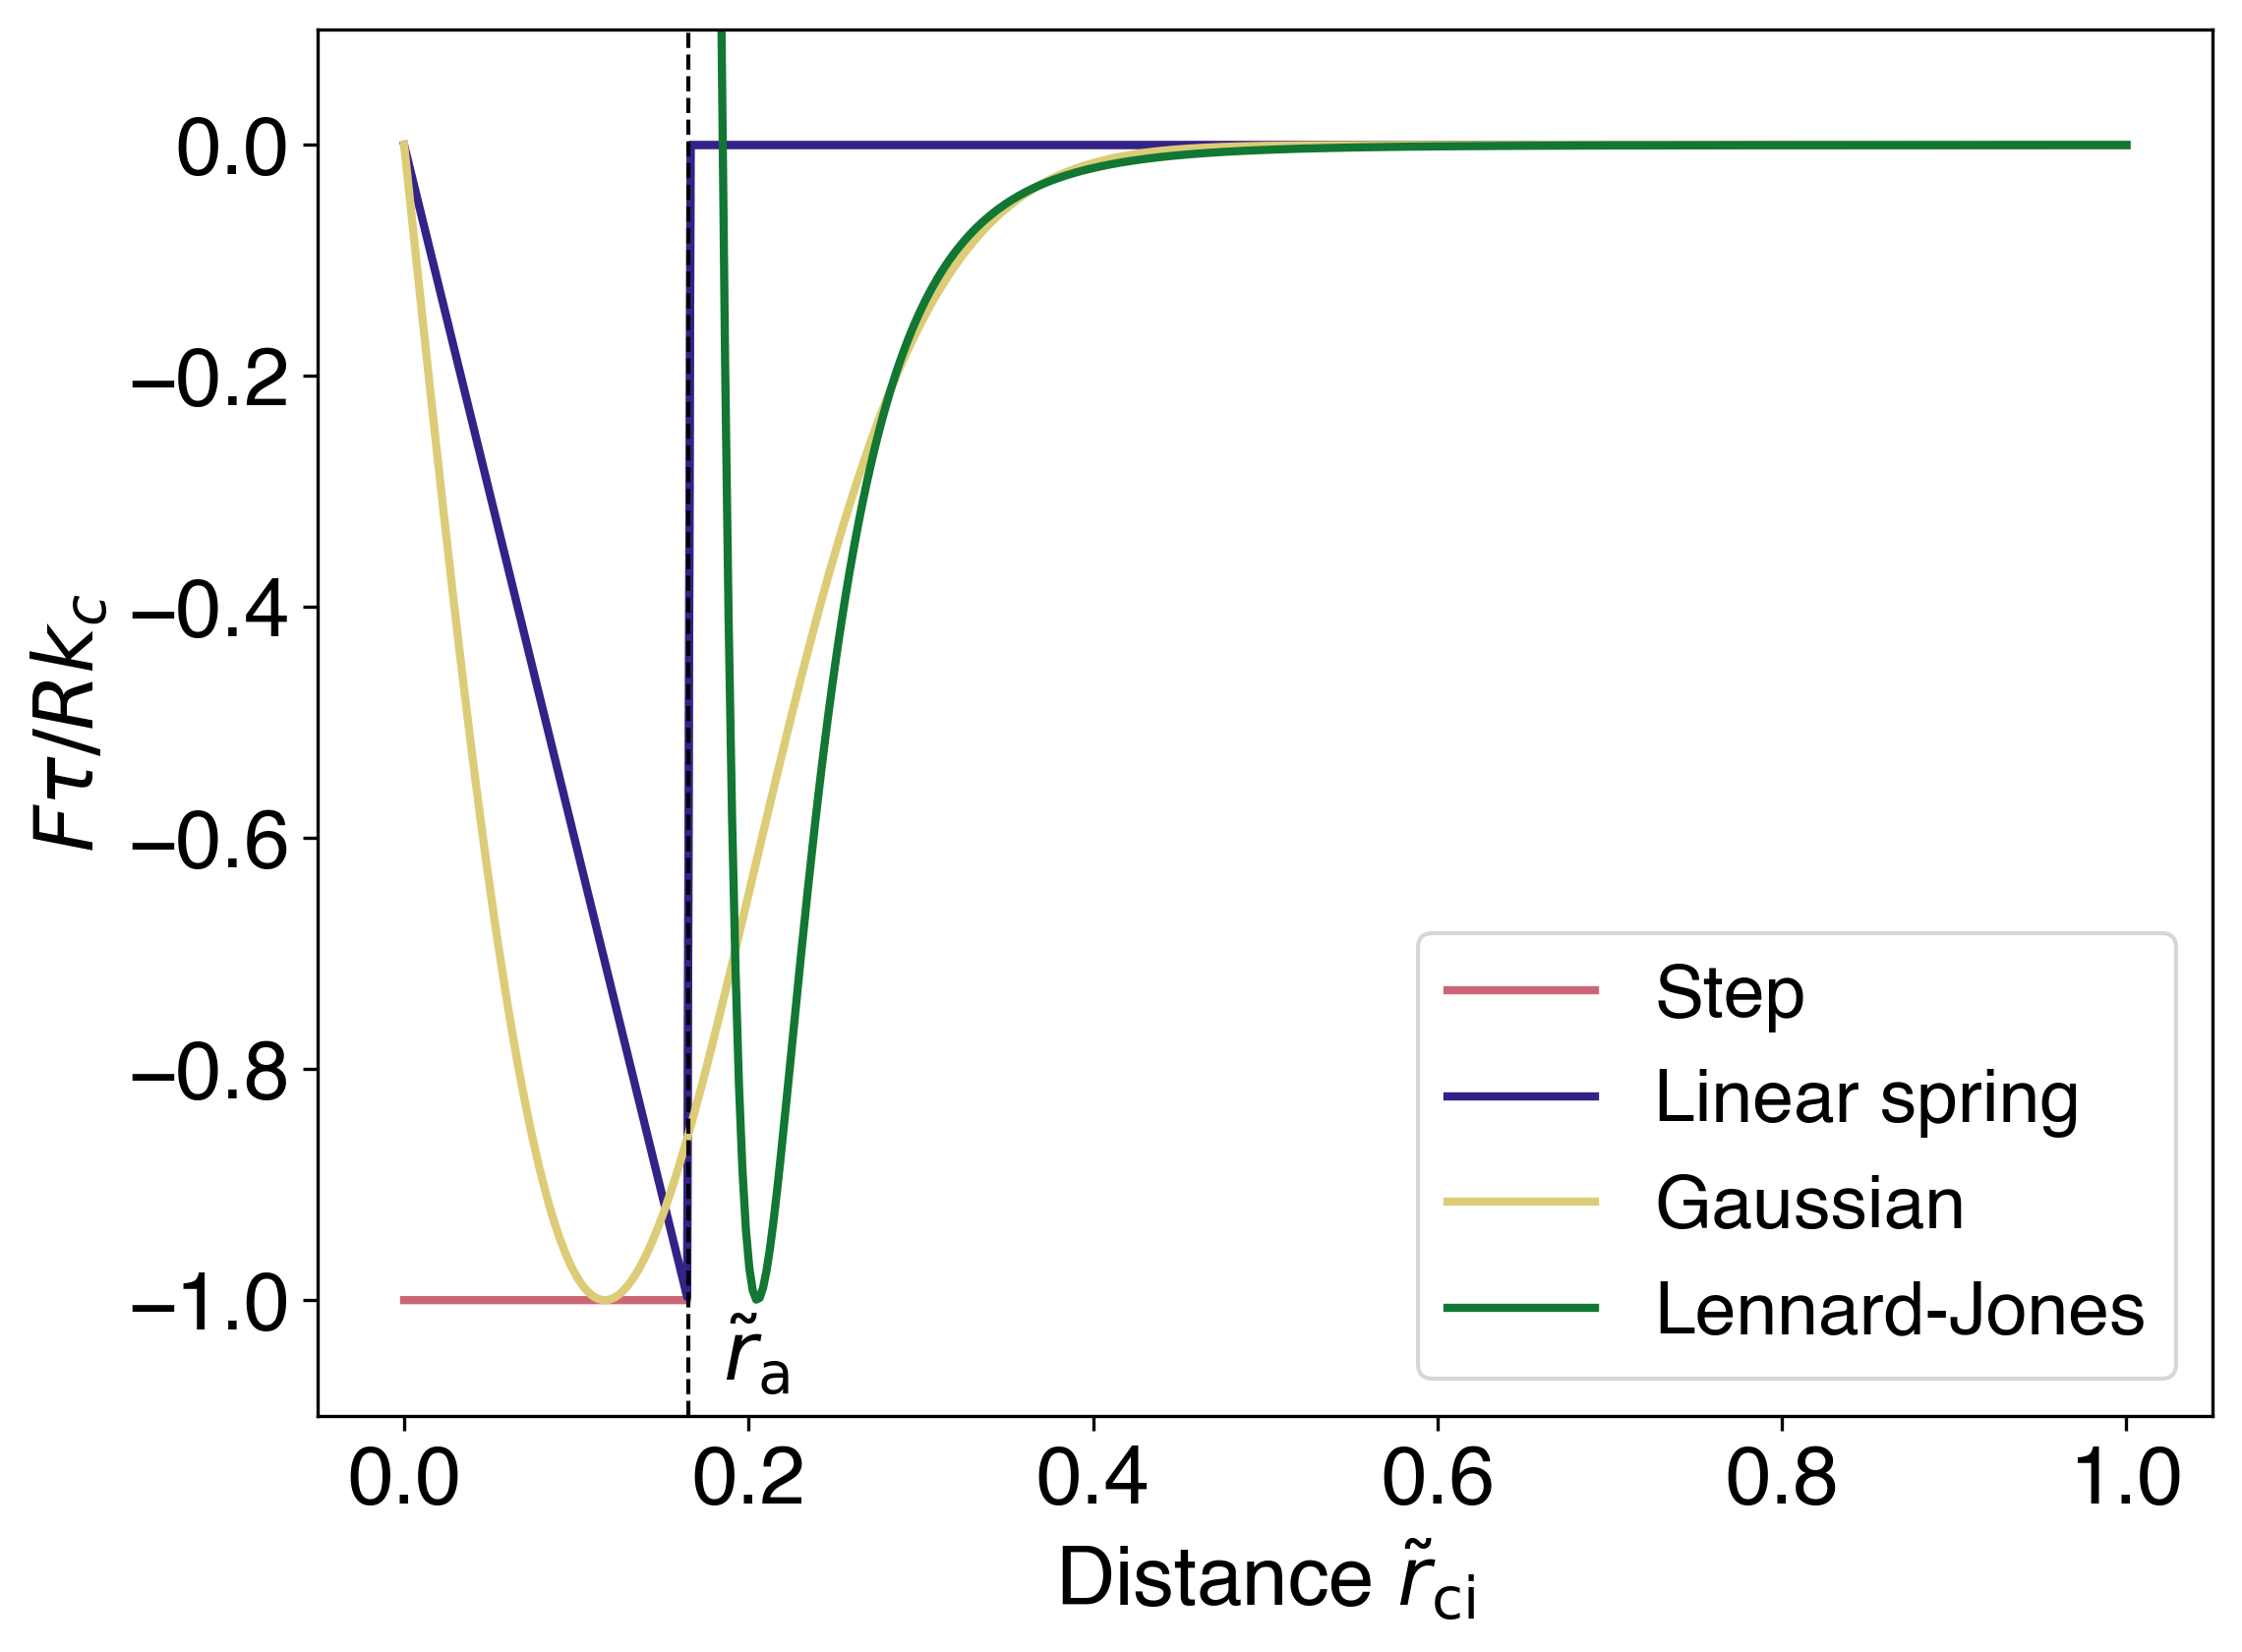

In [40]:
def dna_force_gaussian(epsilon, r, r_a):
    return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)

def dna_force(f, r, r_a):
    if r < r_a:
        return -f
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return -f * r/r_a
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

LJ_distances = distances[distances > r_a*0.9]

ax.plot(LJ_distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in LJ_distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -1.07*f*coefficient, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('$F\\tau/R k_c$')
ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

Coefficient: 0.9999999999999999


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_34809/3154017797.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_34809/3154017797.py:25: RuntimeWarning: invalid value encountered in scalar subtract
  return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))


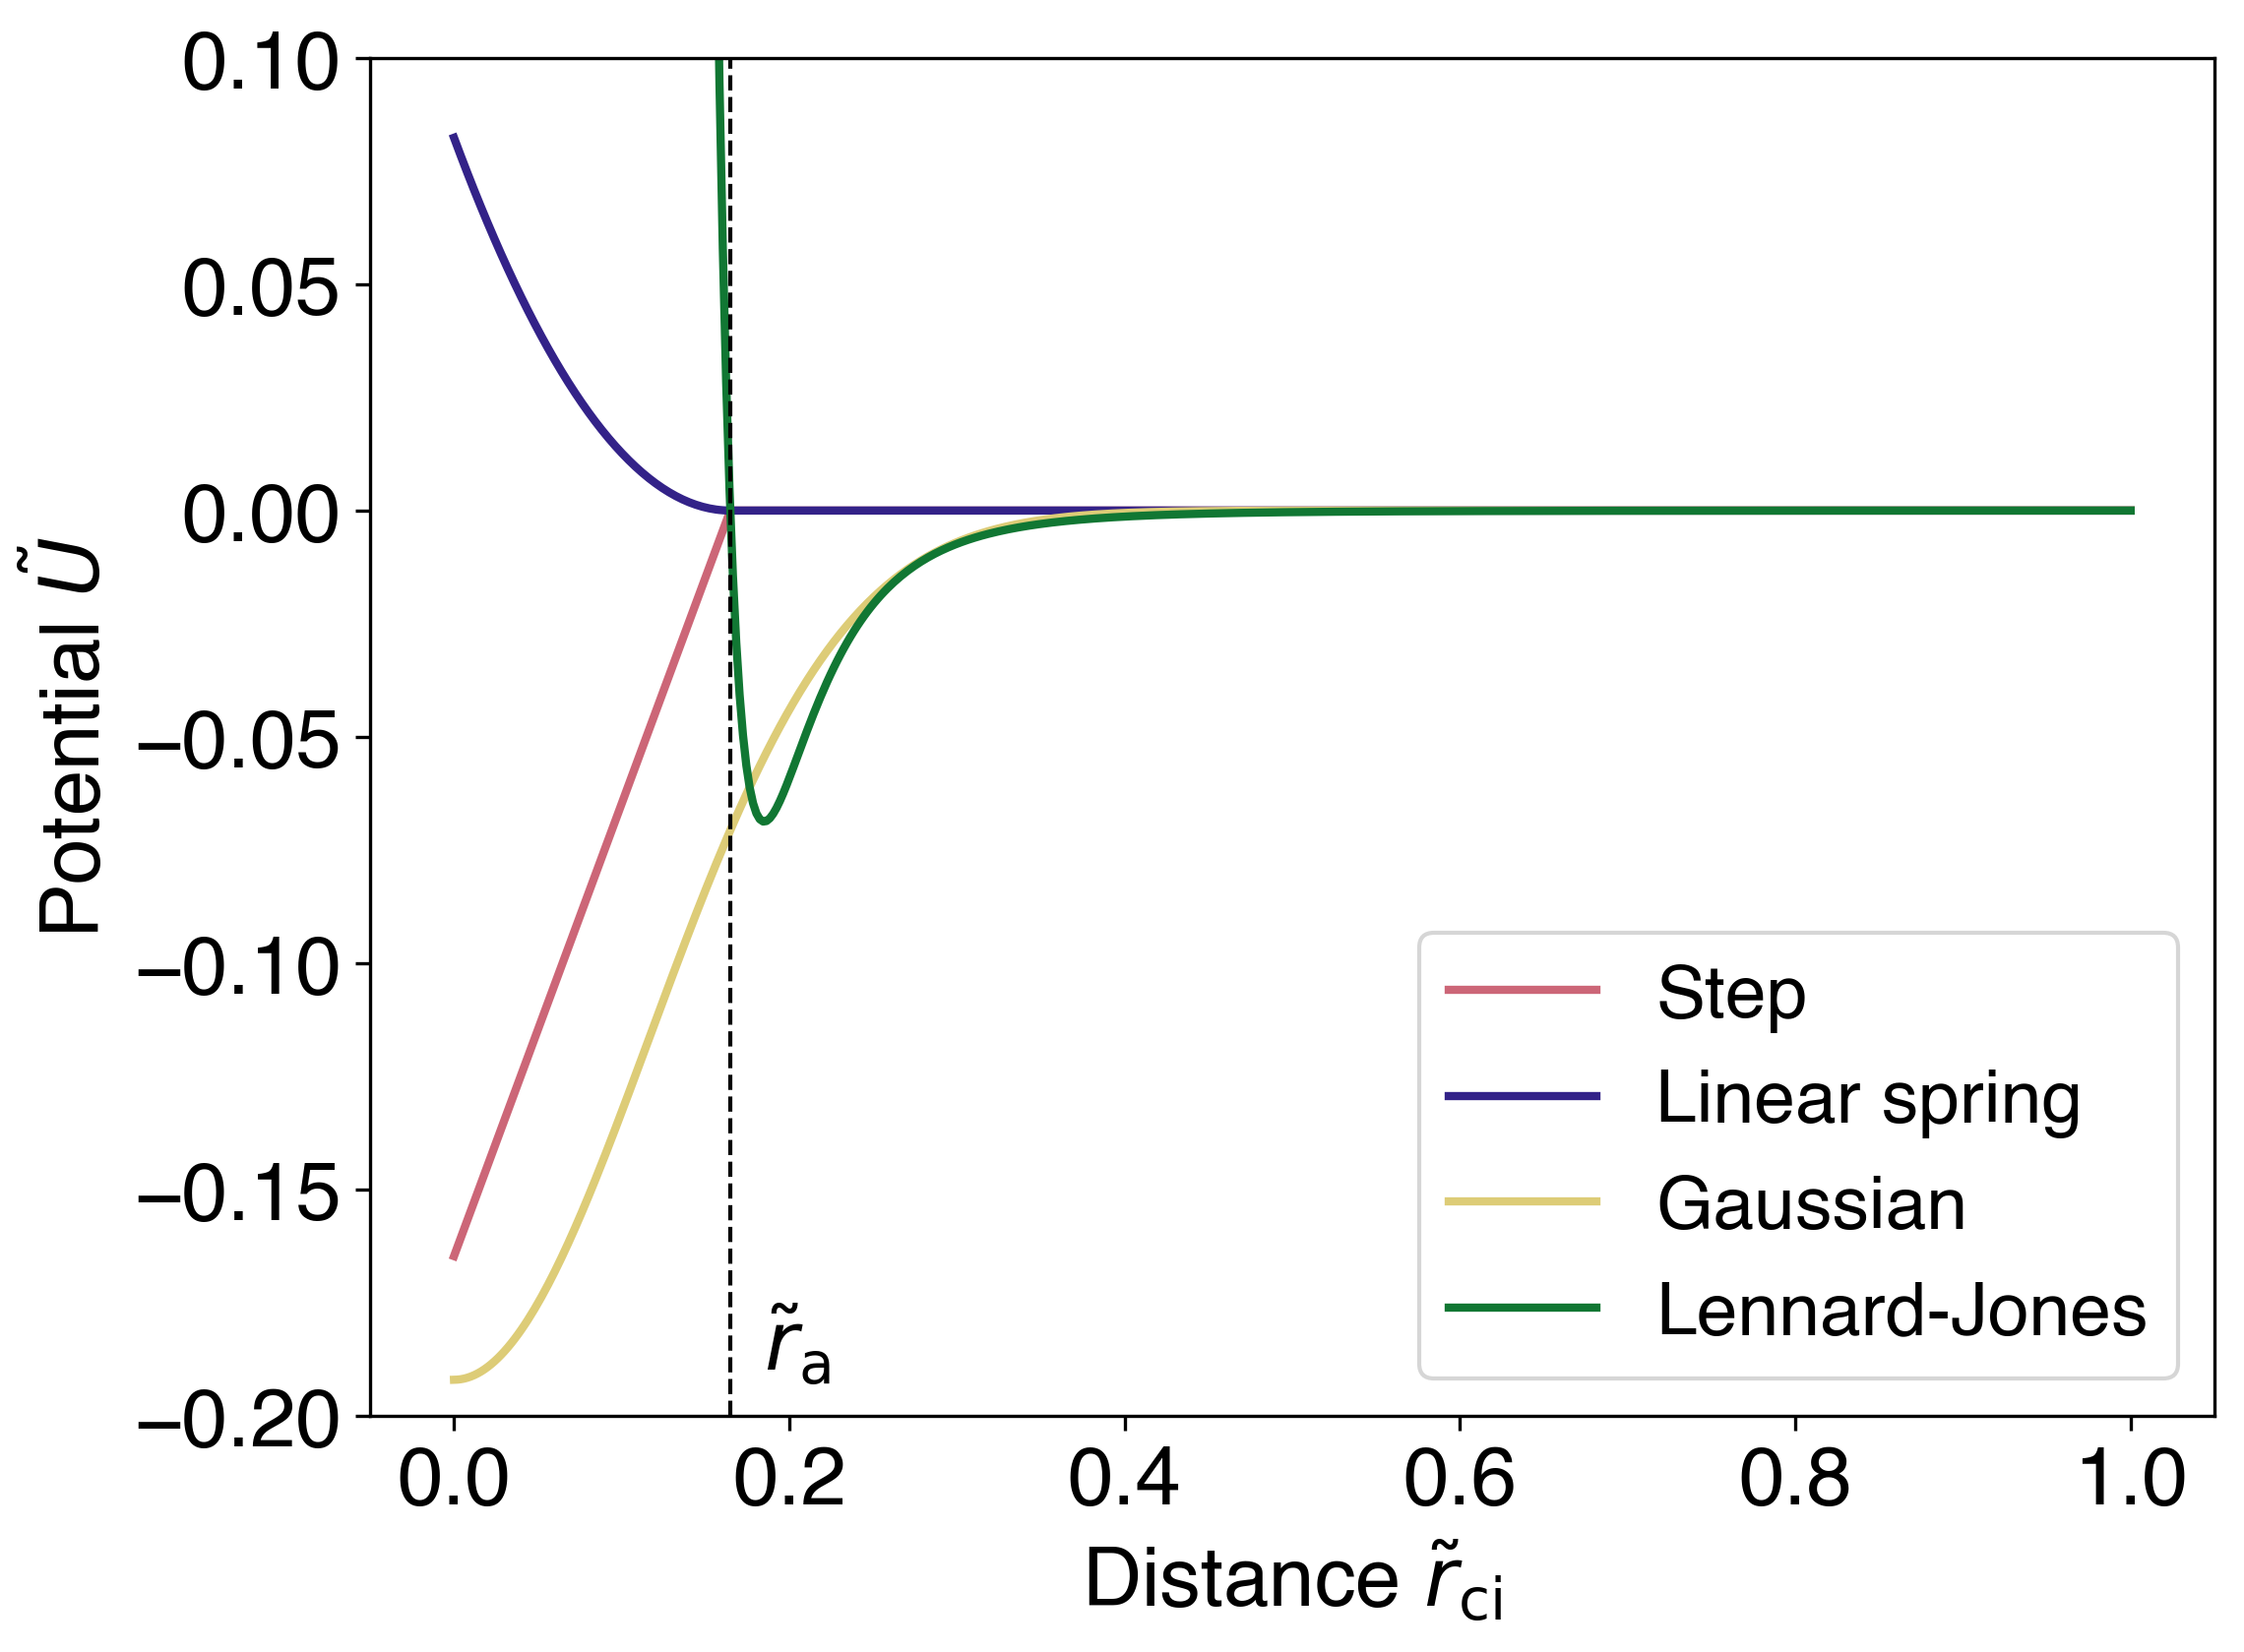

"\nfig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')\nfig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')\n"

In [ ]:
def dna_force_gaussian(epsilon, r, r_a):
    return -epsilon * np.exp(-(r**2)/(r_a**2))

def dna_force(f, r, r_a):
    if r < r_a:
        return f * (r-r_a)
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return f * (r-r_a)**2/(2*r_a)
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

ax.plot(distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -0.19, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('Potential $\\tilde{U}$')
ax.set_ylim(-0.2, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')


In [ ]:
import zarr

data = zarr.open_array("/Volumes/data/Sasaki/backup_git/MTCargoSim/data/MT/P0.5_A0.5/seed1.zarr/orientations", mode='r')
orientations = data[:].T

In [99]:
cos = np.cos(orientations)
sin = np.sin(orientations)

cos2 = 2 * cos**2 - 1
sin2 = 2 * sin * cos

S = np.sqrt(np.mean(cos2, axis=1)**2 + np.mean(sin2, axis=1)**2)

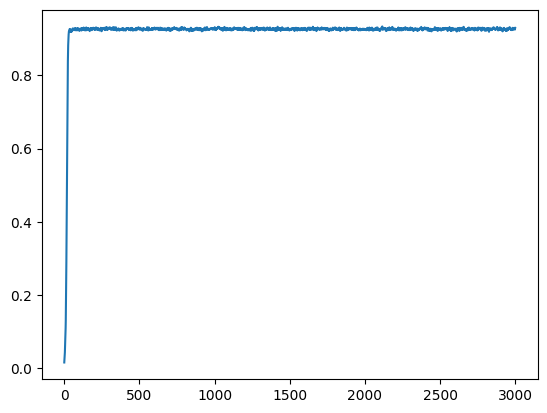

In [100]:
plt.plot(S)

In [111]:
import zarr
import numpy as np
import glob
import os

folder = '/Volumes/My Passport/Sasaki/MTCargoSim/MT/P0.5_A0.1'

def ensembleS(folder):
    S_list = []

    for f in sorted(glob.glob(os.path.join(folder, "seed*.zarr/order_param.zarr"))):
        S = zarr.open_array(f, mode='r')
        S = S[:]
        S_list.append(S)

    return np.array(S_list)

S_mean = []
S_std = []

for A in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    folder = f'/Volumes/My Passport/Sasaki/MTCargoSim/MT/P0.5_A{A:.1f}'
    S = ensembleS(folder)
    S_mean.append(np.mean(S, axis=0))
    S_std.append(np.std(S, axis=0))

[Text(0.5, 0, 'Time step $\\hat{t}$'),
 Text(0, 0.5, 'Order parameter S'),
 (0.0, 1500.0)]

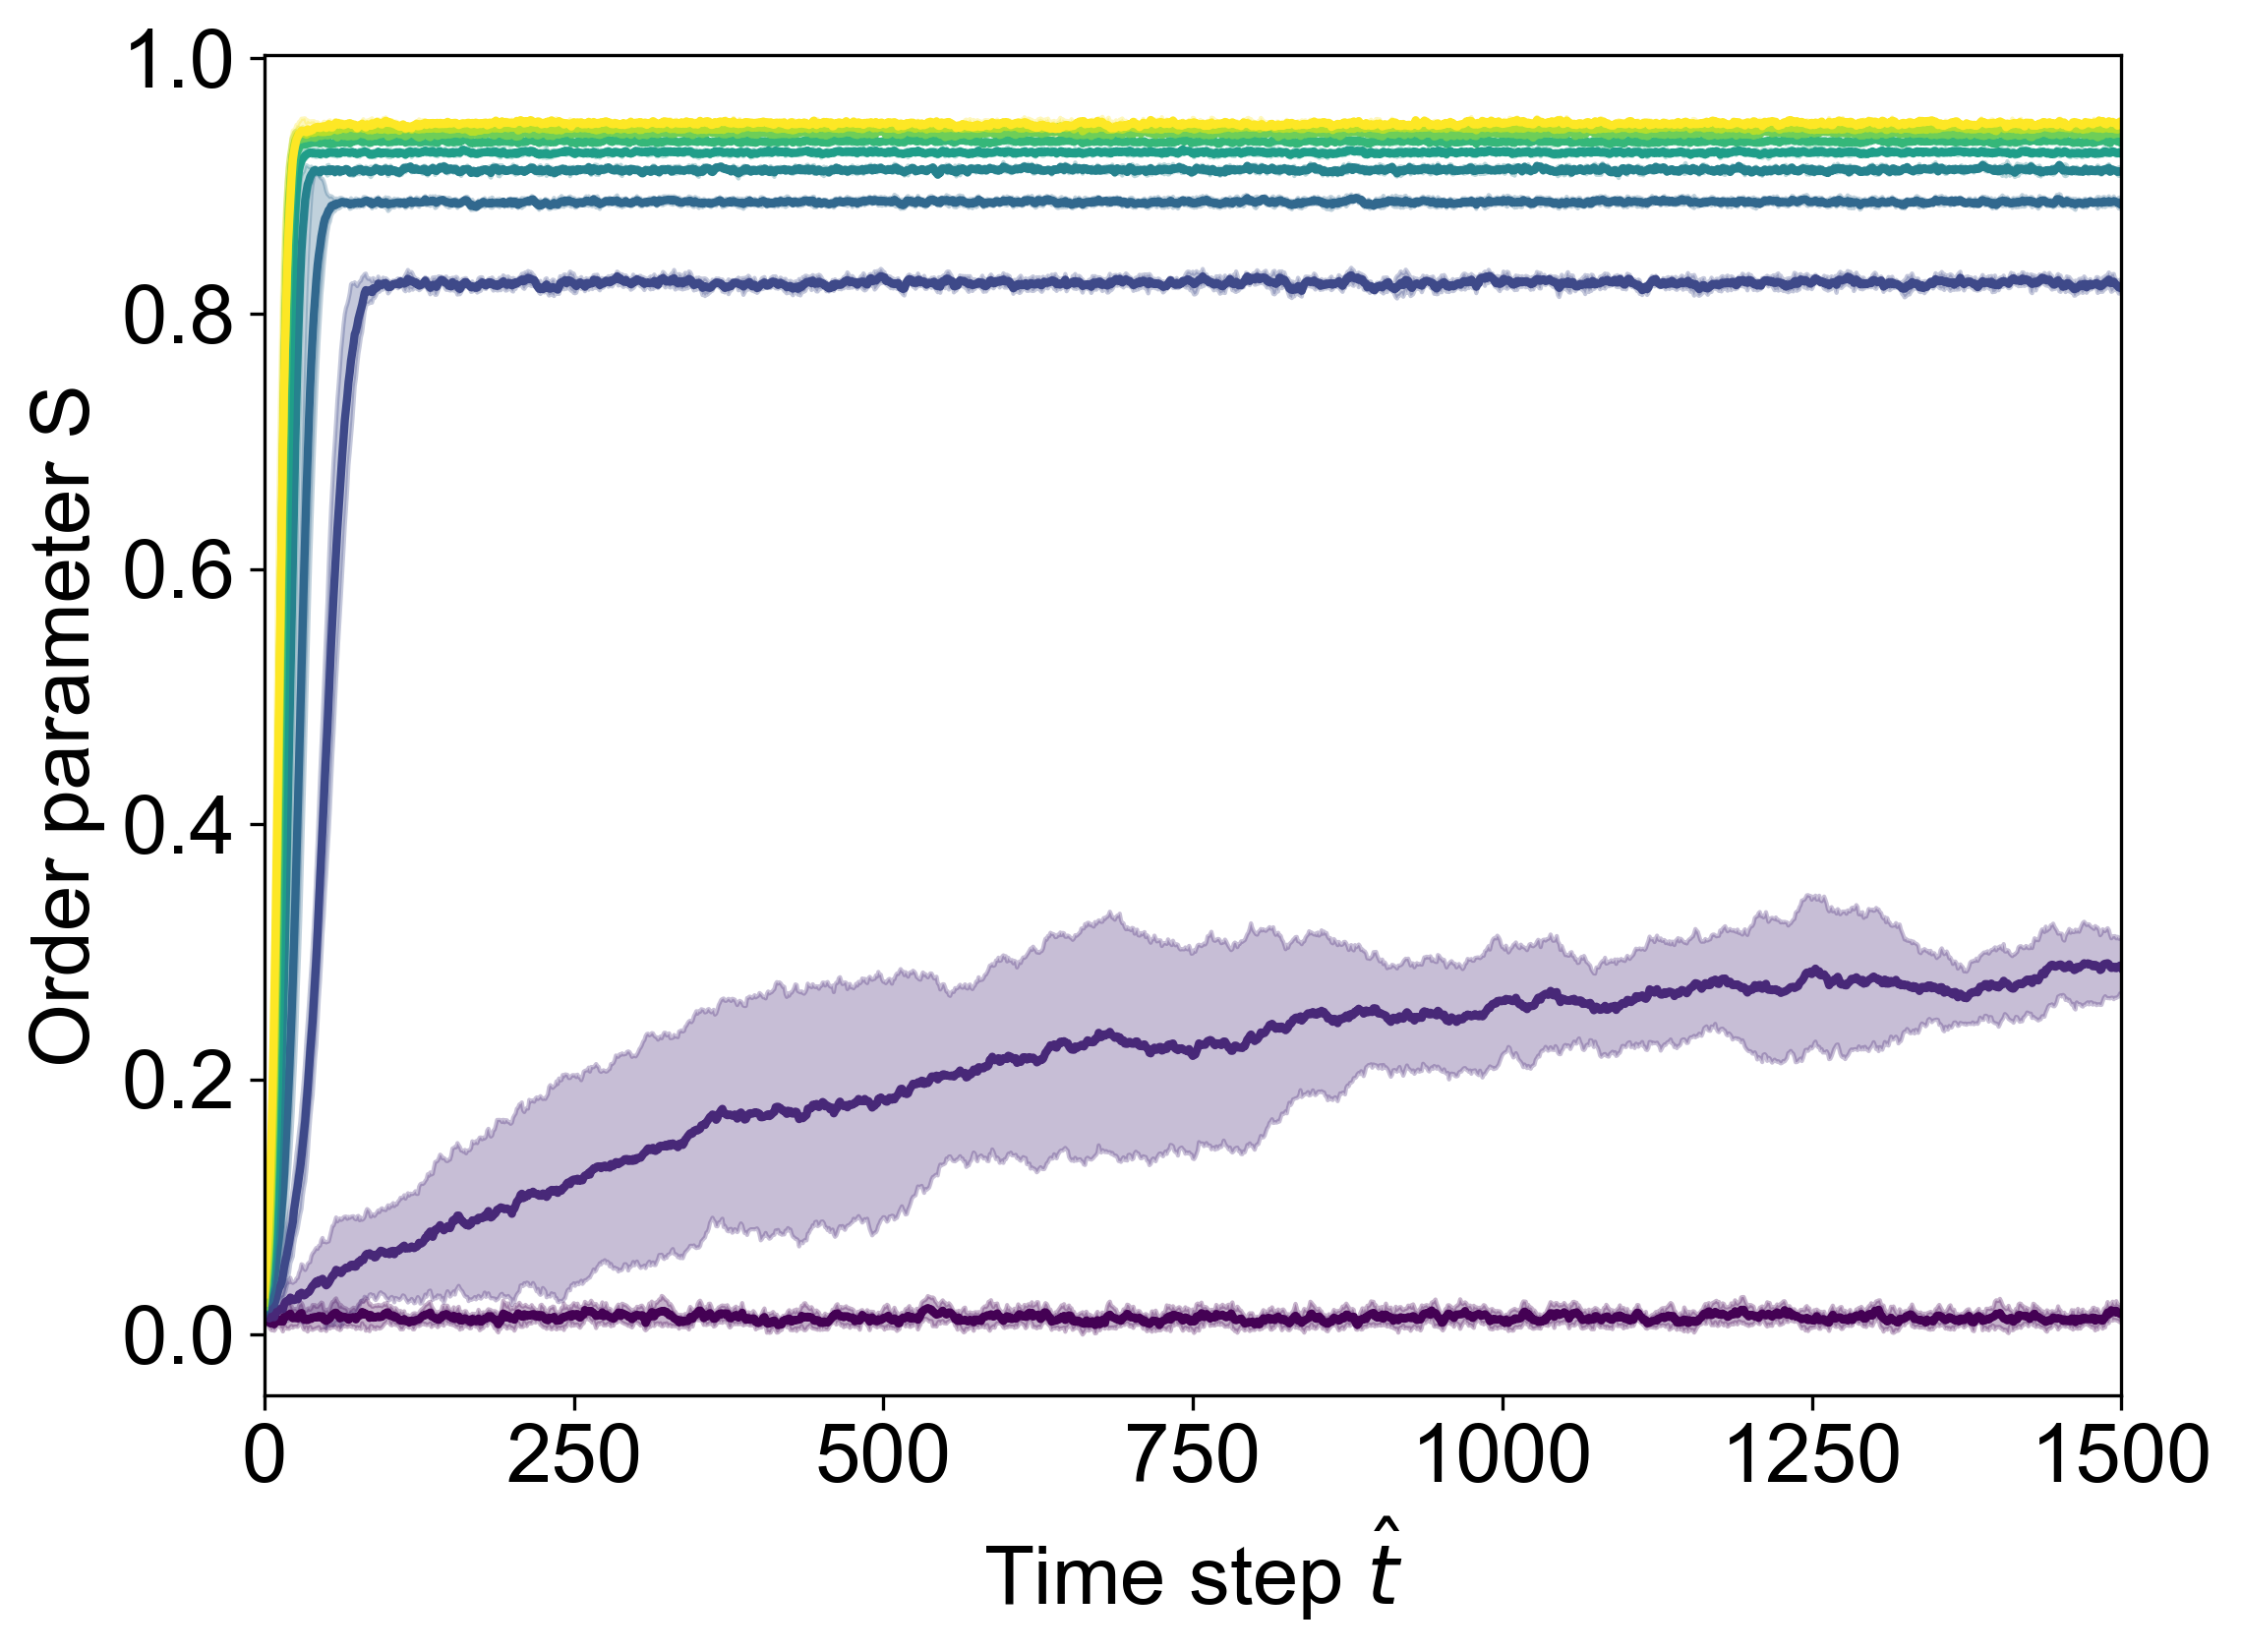

In [118]:
plt.style.use('../my_style.mplstyle')

fig, ax = plt.subplots()

for i in range(len(S_mean)):
    ax.plot(np.arange(len(S_mean[i])), S_mean[i], label=f'A={i*0.1:.1f}', color=plt.cm.viridis(i/9))
    ax.fill_between(np.arange(len(S_mean[i])), S_mean[i] - S_std[i], S_mean[i] + S_std[i], alpha=0.3, color=plt.cm.viridis(i/9))

ax.set(xlabel='Time step $\hat{t}$', ylabel='Order parameter S', xlim = (0, 1500))